In [5]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from sklearn.utils import resample

from torch.profiler import profile, record_function, ProfilerActivity


In [3]:
# Source - https://stackoverflow.com/a/51014127
# Posted by M. Deckers, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-03, License - CC BY-SA 4.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
import matplotlib
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
#import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = True
testing_mode = True
selected_features = False
cat_features = False

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
df_x = df_tv.iloc[:,1:-1]

#df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)
if cat_features:
    categorical_cols = df_x.select_dtypes(['object']).columns
    df_x[categorical_cols] = df_x[categorical_cols].astype('category')
    df_dummy = df_x
    print(categorical_cols)
else:
    df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)

if selected_features:
    df_label = df_tv.replace({'Irrigation_Need': {'Low': 0, 'Medium': 1, 'High': 2}})['Irrigation_Need']
    df_full = pd.concat([df_dummy, df_label], axis=1)
    corr = df_full.corr()
    df_corr_sort_abs = corr.abs().sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
    threshold = 0.1
    df_dummy = df_full[df_corr_sort_abs[df_corr_sort_abs > threshold].index]
    df_dummy.drop(columns=['Irrigation_Need'], inplace=True)
newcolumns = df_dummy.columns.values.tolist() + ['Irrigation_Need']
continous_variables = df_dummy.select_dtypes(['float64']).columns
index = [df_dummy.columns.get_loc(col) for col in continous_variables]

x = df_dummy.iloc[:,:].values
y = df_tv.iloc[:,-1].values

class_le = LabelEncoder()
y = class_le.fit_transform(y)

if testing_mode:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = \
        train_test_split(x, y, 
                        test_size=0.20,
                        stratify=y,
                        random_state=1)
else:
    X_train, y_train = x, y

sc = StandardScaler().fit(X_train[:, index])
X_train[:, index] = sc.transform(X_train[:, index])

if testing_mode:
    X_test[:, index] = sc.transform(X_test[:, index])


if balanced:
    majority_class = np.argmax(np.bincount(y_train))
    minority_class = np.argmin(np.bincount(y_train))
    middle_class = list(set(np.unique(y_train)) - set([majority_class, minority_class]))[0]
    X_train_majority = X_train[y_train == majority_class]
    y_train_majority = y_train[y_train == majority_class]
    
    X_train_minority = X_train[y_train == minority_class]
    y_train_minority = y_train[y_train == minority_class]
    
    X_train_middle = X_train[y_train == middle_class]
    y_train_middle = y_train[y_train == middle_class]
    
    
    X_train_minority_upsampled, y_train_minority_upsampled = resample(X_train_minority, y_train_minority,
                                                                      replace=True,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_majority_downsampled, y_train_majority_downsampled = resample(X_train_majority, y_train_majority,
                                                                      replace=False,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_balanced = np.vstack((X_train_majority_downsampled, X_train_middle, X_train_minority_upsampled))
    y_train_balanced = np.hstack((y_train_majority_downsampled, y_train_middle, y_train_minority_upsampled))

    perm = np.random.permutation(len(X_train_balanced))

    X_train = X_train_balanced[perm]
    y_train = y_train_balanced[perm]

    train_features = np.hstack((X_train, y_train.reshape(-1, 1)))

    df_train = pd.DataFrame(train_features, columns=newcolumns)





In [8]:
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_train.to(device)
y_train.to(device)
train_ds = TensorDataset(X_train, y_train)

batch_size = 256
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
input_size = X_train.shape[1]
hidden_units = [input_size, input_size//2, input_size//4]

all_layers = nn.ModuleList()
#all_layers.append(nn.Flatten())
#all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit
all_layers.append(nn.Linear(hidden_units[-1], len(class_le.classes_)))   
#all_layers.append(nn.Softmax(dim=3))
model = nn.Sequential(*all_layers)
model.to(device)

Sequential(
  (0): Linear(in_features=43, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=3, bias=True)
)

In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch.to(device))
        loss = loss_fn(pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch.to(device)).float()
        accuracy_hist_train += is_correct.sum().cpu()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

Epoch 0  Accuracy 0.9007
Epoch 1  Accuracy 0.9435
Epoch 2  Accuracy 0.9533
Epoch 3  Accuracy 0.9571
Epoch 4  Accuracy 0.9602
Epoch 5  Accuracy 0.9621
Epoch 6  Accuracy 0.9635
Epoch 7  Accuracy 0.9649
Epoch 8  Accuracy 0.9658
Epoch 9  Accuracy 0.9670
Epoch 10  Accuracy 0.9676
Epoch 11  Accuracy 0.9684
Epoch 12  Accuracy 0.9691
Epoch 13  Accuracy 0.9698
Epoch 14  Accuracy 0.9703
Epoch 15  Accuracy 0.9710
Epoch 16  Accuracy 0.9716
Epoch 17  Accuracy 0.9720
Epoch 18  Accuracy 0.9727
Epoch 19  Accuracy 0.9731


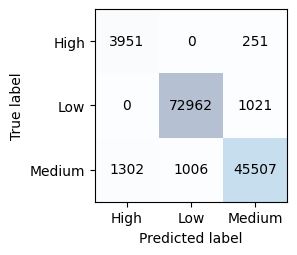

In [11]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

model.to('cpu')
X_test = torch.tensor(X_test).float()
with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)

labels = class_le.inverse_transform(np.unique(y_pred))
confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                           class_le.inverse_transform(y_pred), 
                           sample_weight=None, normalize=None)
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
            va='center', ha='center')
        ax.xaxis.set_ticks_position('bottom')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


In [12]:
if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

torch.save(model, os.path.join(out_dir, 'model_nn_v2.pt'))

In [ ]:
# pred = model(X_test)
# is_correct = (torch.argmax(pred, dim=1) == y_test).float()
# print(f'Test accuracy: {is_correct.mean():.4f}') 

In [13]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values


df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], dtype=int)
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = torch.tensor(df_test_dummy.to_numpy()).float()
#x_test.to(device)

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [14]:
model.to('cpu')
with torch.no_grad():   
    df_submission_nn = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(torch.argmax(model(x_test), dim=1))})
    df_submission_nn.to_csv(os.path.join(out_dir, 'submission-nn_v3.csv'), index=False)